# Pipeline Final — Copa FutBotMX
## Visión por Computadora: Segmentación, Tracking y Análisis Táctico

**Equipo:** *Los más 3D*  
**Categoría:** Amateur  
**Video procesado:** Vista cenital con cámara fija

Este notebook integra el pipeline completo:
1. **YucaBot** (YOLOv8m fine-tuned) para detección de robots y balón
2. **SAM 3** para segmentación con máscaras precisas
3. **ByteTrack** para tracking continuo entre frames
4. **Mapa táctico** con proyección geométrica y vista cenital
5. **Visualizaciones** de heatmap y trayectorias


In [107]:
import warnings
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import supervision as sv
import torch
from pathlib import Path
from ultralytics import YOLO, SAM
from ultralytics.models.sam import SAM3SemanticPredictor
from collections import defaultdict, Counter

Path("assets").mkdir(exist_ok=True)

print(f"Supervision: {sv.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Supervision: 0.28.0
PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5050


## 1. Configuración global

In [108]:
# ── Rutas ─────────────────────────────────────────────────────────────────
VIDEO_PATH     = "../VideosEjemplo/cenital_Analisis.mp4"
OUTPUT_PIPELINE = "assets/pipeline_final.mp4"
OUTPUT_HEATMAP  = "assets/heatmap_final.png"
OUTPUT_TRAILS   = "assets/trails_final.png"

# ── Campo canónico (vista cenital) ─────────────────────────────────────────
# Dimensiones en píxeles del mapa táctico (basadas en cancha real FutBotMX)
CAMPO_W, CAMPO_H = 810, 1080
ESCALA_PX_CM = 4.0  # 1 cm real = 4 px en el campo canónico

TARGET_POINTS = np.float32([
    [0,       0      ],  # TL
    [CAMPO_W, 0      ],  # TR
    [CAMPO_W, CAMPO_H],  # BR
    [0,       CAMPO_H],  # BL
])

# ── Puntos SOURCE en el video cenital.mp4 (vista cenital fija) ───────────────
# Estos puntos corresponden a las 4 esquinas de la cancha en el video
# Ajusta si usas un video distinto
SOURCE_POINTS = np.float32([
    [ 200,  240],   # esquina superior-izquierda
    [1070,   250],   # esquina superior-derecha
    [1050, 1790],   # esquina inferior-derecha
    [ 20,  1600],   # esquina inferior-izquierda
])

# ── Colores por clase (BGR) ────────────────────────────────────────────────
# class 0 = ball, class 1 = robot
COLORS_BGR = {
    0: (0,   200, 255),   # balón  → naranja
    1: (239,  35,  60),   # robot  → rojo/azul alternado por tracker_id
}

# ── Margen para porterías (fuera del rectángulo de la matriz H) ───────────
MARGEN_PORTERIA_PX = int(20 * ESCALA_PX_CM)  # profundidad de la portería en px

# Dimensiones totales del canvas (cancha + porterías arriba y abajo)
CANVAS_H = CAMPO_H + (2 * MARGEN_PORTERIA_PX)
MARGEN_LATERAL_PX  = int(15 * ESCALA_PX_CM)
CANVAS_W = CAMPO_W + (2 * MARGEN_LATERAL_PX)

# Calcular matriz de homografía
H_matrix = cv2.getPerspectiveTransform(SOURCE_POINTS, TARGET_POINTS)
print("✓ Configuración lista")
print(f"  Campo canónico: {CAMPO_W}×{CAMPO_H} px")
print(f"  Matriz H calculada")


✓ Configuración lista
  Campo canónico: 810×1080 px
  Matriz H calculada


## 2. Verificar puntos SOURCE sobre el video

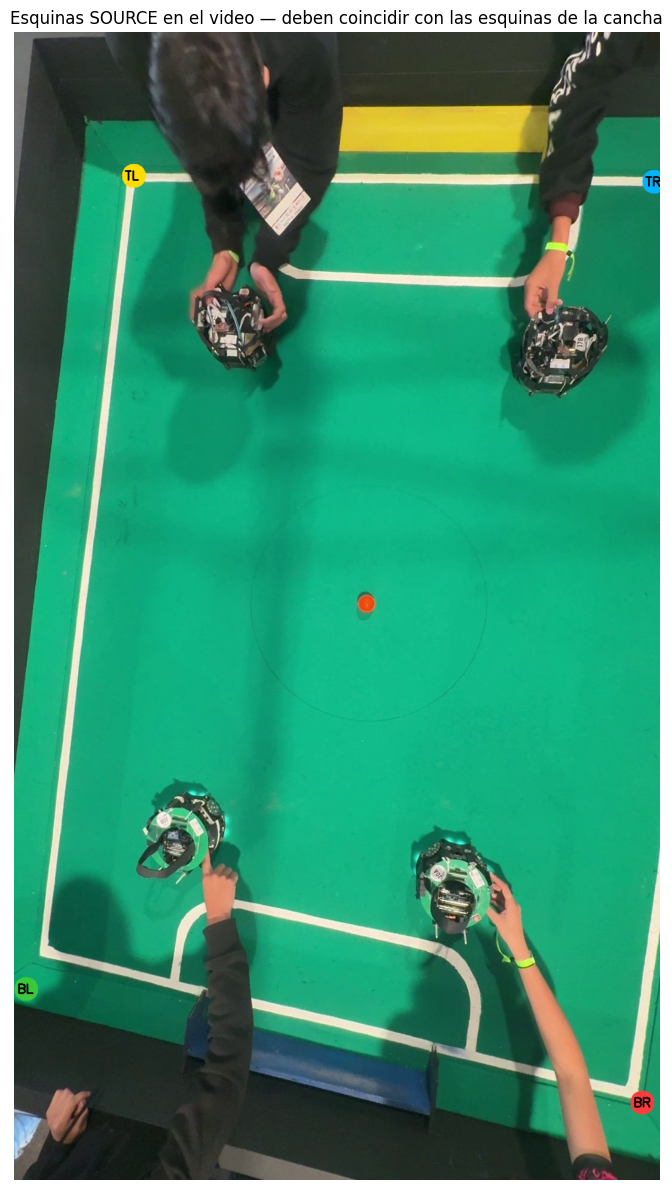

Si los puntos no coinciden con las esquinas, ajusta SOURCE_POINTS en la celda anterior


In [109]:
# Verificar que los puntos SOURCE están bien colocados
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, frame_check = cap.read()
cap.release()

vis = cv2.cvtColor(frame_check, cv2.COLOR_BGR2RGB).copy()
colores_vis = [(255, 220, 0), (0, 180, 255), (255, 60, 60), (60, 200, 60)]
nombres = ["TL", "TR", "BR", "BL"]

for idx, (pt, color, nombre) in enumerate(zip(SOURCE_POINTS, colores_vis, nombres)):
    x, y = int(pt[0]), int(pt[1])
    cv2.circle(vis, (x, y), 20, color, -1)
    cv2.putText(vis, nombre, (x-15, y+7), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)

plt.figure(figsize=(8, 12))
plt.imshow(vis)
plt.title("Esquinas SOURCE en el video — deben coincidir con las esquinas de la cancha")
plt.axis("off")
plt.tight_layout()
plt.savefig("assets/verificacion_source_points.png", dpi=100, bbox_inches="tight")
plt.show()
print("Si los puntos no coinciden con las esquinas, ajusta SOURCE_POINTS en la celda anterior")


## 3. Cargar modelos

In [110]:
# ── YucaBot (detector especializado) ──────────────────────────────────────
yolo_model = YOLO("../yucabot.pt")
print(f"✓ YucaBot cargado — clases: {yolo_model.names}")

# ── SAM 3 (segmentador) ────────────────────────────────────────────────────
sam_model = SAM("sam3.pt")
print("✓ SAM 3 cargado")

# ── Anotadores ────────────────────────────────────────────────────────────
mask_annotator  = sv.MaskAnnotator(opacity=0.45)
box_annotator   = sv.BoxAnnotator(thickness=2)
label_annotator = sv.LabelAnnotator(text_scale=0.5)
trace_annotator = sv.TraceAnnotator(thickness=2, trace_length=40)

# ── Tracker ───────────────────────────────────────────────────────────────
tracker = sv.ByteTrack(lost_track_buffer=90)
tracker.reset()

# ── Memoria para interpolación ────────────────────────────────────────────
ultima_det_valida = None
frames_sin_det    = 0
MAX_FRAMES_SIN_DET = 15

print("Todo listo para procesar")


✓ YucaBot cargado — clases: {0: 'ball', 1: 'robot'}
✓ SAM 3 cargado
Todo listo para procesar


## Clasificación de equipos

In [111]:
# ── Clasificación de equipos por primer frame ─────────────────────────────
# Equipo 1 = mitad superior del campo canónico (Y < CAMPO_H/2) → Amarillo
# Equipo 2 = mitad inferior del campo canónico (Y >= CAMPO_H/2) → Azul

TEAM_COLORS_BGR = {
    1: (0,   212, 255),  # Equipo 1 → Amarillo
    2: (255, 100,   0),  # Equipo 2 → Azul
}

In [112]:
# ── project_point va aquí porque clasificar_desde_primer_frame la necesita ──
def project_point(x: float, y: float, H: np.ndarray):
    """Proyecta un punto del video al campo canónico usando la homografía H."""
    pt   = np.float32([[[x, y]]])
    proj = cv2.perspectiveTransform(pt, H)
    return int(proj[0][0][0]), int(proj[0][0][1])


from collections import defaultdict, deque

robot_team_map = {}  # tracker_id -> equipo asignado (fijo una vez decidido)

# Historial de posiciones recientes por tracker_id, usado solo para heredar
# el equipo cuando aparece un ID nuevo y hay que buscar "quién era" antes.
VENTANA_HERENCIA = 30  # frames a considerar para buscar el robot más cercano
posicion_historial = defaultdict(lambda: deque(maxlen=VENTANA_HERENCIA))

# Distancia máxima (en px del campo canónico) para considerar que un ID nuevo
# es "el mismo robot" que uno que desapareció recientemente.
DISTANCIA_MAX_HERENCIA = 120


def clasificar_robot(tracker_id: int, px: int, py: int) -> int:
    # ── Caso 1: ya conocemos este tracker_id — mantener su equipo fijo ────
    if tracker_id in robot_team_map:
        posicion_historial[tracker_id].append((px, py))
        return robot_team_map[tracker_id]

    # ── Caso 2: tracker_id nuevo — buscar el robot conocido más cercano ───
    mejor_id        = None
    mejor_distancia  = float("inf")

    for tid_conocido, historial in posicion_historial.items():
        if tid_conocido == tracker_id or not historial:
            continue
        # Comparar contra la última posición conocida de ese robot
        ult_px, ult_py = historial[-1]
        dist = ((px - ult_px) ** 2 + (py - ult_py) ** 2) ** 0.5

        if dist < mejor_distancia:
            mejor_distancia = dist
            mejor_id         = tid_conocido

    if mejor_id is not None and mejor_distancia <= DISTANCIA_MAX_HERENCIA:
        # Heredar el equipo del robot más cercano dentro del umbral
        equipo_heredado = robot_team_map[mejor_id]
        robot_team_map[tracker_id] = equipo_heredado
        print(f"  ID nuevo {tracker_id} hereda Equipo {equipo_heredado} "
              f"de ID anterior {mejor_id} (dist={mejor_distancia:.0f}px)")
    else:
        # No hay candidato cercano — clasificar por posición actual (caso real nuevo robot)
        equipo_heredado = 1 if py < CAMPO_H // 2 else 2
        robot_team_map[tracker_id] = equipo_heredado
        print(f"  ID nuevo {tracker_id} → Equipo {equipo_heredado} (sin candidato cercano)")

    posicion_historial[tracker_id].append((px, py))
    return robot_team_map[tracker_id]


def clasificar_desde_primer_frame(frame: np.ndarray):
    global robot_team_map, posicion_historial
    robot_team_map = {}
    posicion_historial = defaultdict(lambda: deque(maxlen=VENTANA_HERENCIA))

    res = yolo_model(frame, verbose=False)[0]
    det = sv.Detections.from_ultralytics(res)
    det = det[det.confidence >= 0.50]
    det = det[det.class_id == 1]

    if len(det) == 0:
        print("No se detectaron robots en el primer frame — clasificación diferida")
        return

    for i, box in enumerate(det.xyxy):
        cx = (box[0] + box[2]) / 2
        cy = box[3]
        px, py = project_point(cx, cy, H_matrix)
        equipo = 1 if py < CAMPO_H // 2 else 2
        robot_team_map[i + 1] = equipo
        posicion_historial[i + 1].append((px, py))
        print(f"  Robot {i+1} → Equipo {equipo} (py={py})")

    print(f"✓ Clasificación inicial: {robot_team_map}")


# Ejecutar sobre el primer frame
cap_init = cv2.VideoCapture(VIDEO_PATH)
ret_init, frame_init = cap_init.read()
cap_init.release()

if ret_init:
    clasificar_desde_primer_frame(frame_init)
else:
    print("No se pudo leer el primer frame")

  Robot 1 → Equipo 1 (py=282)
  Robot 2 → Equipo 1 (py=296)
  Robot 3 → Equipo 2 (py=930)
  Robot 4 → Equipo 2 (py=945)
✓ Clasificación inicial: {1: 1, 2: 1, 3: 2, 4: 2}


## Funciones auxiliares

In [113]:
def project_detections(detections: sv.Detections, H: np.ndarray) -> list:
    """Proyecta todas las detecciones al campo canónico."""
    puntos = []
    if len(detections) == 0 or detections.tracker_id is None:
        return puntos

    for box, cid, tid in zip(detections.xyxy, detections.class_id, detections.tracker_id):
        cx = (box[0] + box[2]) / 2
        cy = box[3] if int(cid) == 1 else (box[1] + box[3]) / 2

        px, py = project_point(cx, cy, H)

        # ← determinar equipo para asignar color correcto
        if int(cid) == 1:  # robot
            equipo = clasificar_robot(int(tid), py)
            color  = TEAM_COLORS_BGR[equipo]
        else:              # balón
            equipo = 0
            color  = (0, 200, 255)  # naranja

        puntos.append({
            "pos"       : (px, py),
            "class_id"  : int(cid),
            "tracker_id": int(tid),
            "equipo"    : equipo,
            "color"     : color,
        })
    return puntos


def draw_tactical_canvas(puntos: list, heatmap_acc: np.ndarray = None) -> np.ndarray:
    canvas = np.zeros((CANVAS_H, CANVAS_W, 3), dtype=np.uint8)
    canvas[:] = (109, 167, 1)

    x_offset = MARGEN_LATERAL_PX
    y_offset = MARGEN_PORTERIA_PX

    # ── Cancha real, desplazada por ambos márgenes ──────────────────────────
    cv2.rectangle(canvas,
                  (x_offset, y_offset),
                  (x_offset + CAMPO_W - 1, y_offset + CAMPO_H - 1),
                  (109, 167, 1), -1)
    cv2.rectangle(canvas,
                  (x_offset, y_offset),
                  (x_offset + CAMPO_W - 1, y_offset + CAMPO_H - 1),
                  (120, 200, 116), 2)

    cv2.line(canvas,
             (x_offset, y_offset + CAMPO_H//2),
             (x_offset + CAMPO_W, y_offset + CAMPO_H//2),
             (120, 200, 116), 1)
    cv2.circle(canvas,
               (x_offset + CAMPO_W//2, y_offset + CAMPO_H//2),
               int(30*ESCALA_PX_CM), (120, 200, 116), 1)

    # ── Porterías ────────────────────────────────────────────────────────────
    gw = int(60 * ESCALA_PX_CM)
    gx = x_offset + (CAMPO_W - gw) // 2

    cv2.rectangle(canvas, (gx, 0), (gx+gw, y_offset),
                  TEAM_COLORS_BGR[1], 3)
    cv2.rectangle(canvas, (gx, y_offset + CAMPO_H), (gx+gw, CANVAS_H - 1),
                  TEAM_COLORS_BGR[2], 3)

    # ── Dibujar objetos con offset en X e Y ─────────────────────────────────
    MARGEN_TOLERANCIA = 30

    for p in puntos:
        x_orig, y_orig = p["pos"]
        cid = p["class_id"]
        tid = p["tracker_id"]

        x = x_orig + x_offset
        y = y_orig + y_offset

        if not (-MARGEN_TOLERANCIA <= x_orig < CAMPO_W + MARGEN_TOLERANCIA and
                -MARGEN_PORTERIA_PX - MARGEN_TOLERANCIA <= y_orig < CAMPO_H + MARGEN_PORTERIA_PX + MARGEN_TOLERANCIA):
            continue

        x_draw = max(0, min(CANVAS_W - 1, x))
        y_draw = max(0, min(CANVAS_H - 1, y))

        color = p["color"]
        r = 28 if cid == 1 else 18

        cv2.circle(canvas, (x_draw, y_draw), r, color, -1)
        cv2.circle(canvas, (x_draw, y_draw), r, (255, 255, 255), 1)
        if cid == 1:
            cv2.putText(canvas, str(tid), (x_draw-8, y_draw+6),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    return canvas


# Acumuladores para heatmap y trails
heatmap_acc   = np.zeros((CAMPO_H, CAMPO_W), dtype=np.float32)
trails_canvas = np.zeros((CAMPO_H, CAMPO_W, 3), dtype=np.uint8)
trails_canvas[:] = (50, 67, 27)
cv2.rectangle(trails_canvas, (0, 0), (CAMPO_W-1, CAMPO_H-1), (120, 200, 116), 2)
cv2.line(trails_canvas, (0, CAMPO_H//2), (CAMPO_W, CAMPO_H//2), (120, 200, 116), 1)

print("✓ Funciones auxiliares definidas")

✓ Funciones auxiliares definidas


## PolygonZone de porterías

In [114]:
import supervision as sv
import numpy as np

# ── Porterías en coordenadas del campo canónico ───────────────────────────
# Portería superior (Equipo 1 defiende) → color Amarillo
# Portería inferior (Equipo 2 defiende) → color Azul

ANCHO_PORTERIA_PX  = int(60 * ESCALA_PX_CM)
GROSOR_PORTERIA_PX = MARGEN_PORTERIA_PX  # toda la profundidad del margen es zona de gol
ANCHO_PORTERIA_PX  = int(60 * ESCALA_PX_CM)
gx                 = (CAMPO_W - ANCHO_PORTERIA_PX) // 2

# Portería superior — en coordenadas NEGATIVAS porque está antes de y=0
porteria_superior_poly = np.array([
    [gx,                     -MARGEN_PORTERIA_PX],
    [gx + ANCHO_PORTERIA_PX, -MARGEN_PORTERIA_PX],
    [gx + ANCHO_PORTERIA_PX, 0                  ],
    [gx,                     0                  ],
], dtype=np.int32)

# Portería inferior — coordenadas después de CAMPO_H
porteria_inferior_poly = np.array([
    [gx,                     CAMPO_H                    ],
    [gx + ANCHO_PORTERIA_PX, CAMPO_H                    ],
    [gx + ANCHO_PORTERIA_PX, CAMPO_H + MARGEN_PORTERIA_PX],
    [gx,                     CAMPO_H + MARGEN_PORTERIA_PX],
], dtype=np.int32)

zone_superior = sv.PolygonZone(polygon=porteria_superior_poly)
zone_inferior = sv.PolygonZone(polygon=porteria_inferior_poly)

# Contadores de goles
goles_equipo1 = 0  # gol en portería inferior (Equipo 2 defiende)
goles_equipo2 = 0  # gol en portería superior (Equipo 1 defiende)

# Control de cooldown para no contar el mismo gol varias veces
COOLDOWN_FRAMES   = 150
ultimo_gol_frame  = -COOLDOWN_FRAMES

print(f"✓ Porterías configuradas")
print(f"  Superior: x=[{gx}, {gx+ANCHO_PORTERIA_PX}] y=[0, {GROSOR_PORTERIA_PX}]")
print(f"  Inferior: x=[{gx}, {gx+ANCHO_PORTERIA_PX}] y=[{CAMPO_H-GROSOR_PORTERIA_PX}, {CAMPO_H}]")

✓ Porterías configuradas
  Superior: x=[285, 525] y=[0, 80]
  Inferior: x=[285, 525] y=[1000, 1080]


## 5. Pipeline principal

In [115]:
def pipeline_callback_dummy():
    pass  # pipeline ahora está integrado en el loop — ver celda de procesamiento
print("✓ Listo — pipeline integrado en el loop de procesamiento")

✓ Listo — pipeline integrado en el loop de procesamiento


## 6. Procesar video completo

In [116]:
import time
import openpyxl
from openpyxl import Workbook

# ── Resetear todo ─────────────────────────────────────────────────────────
tracker.reset()
robot_team_map    = {}
heatmap_acc[:]    = 0
trails_canvas[:]  = (50, 67, 27)
cv2.rectangle(trails_canvas, (0, 0), (CAMPO_W-1, CAMPO_H-1), (120, 200, 116), 2)
cv2.line(trails_canvas, (0, CAMPO_H//2), (CAMPO_W, CAMPO_H//2), (120, 200, 116), 1)
ultima_det_valida = None
frames_sin_det    = 0
goles_equipo1     = 0
goles_equipo2     = 0
ultimo_gol_frame  = -COOLDOWN_FRAMES

# ── Excel ─────────────────────────────────────────────────────────────────
wb = Workbook()
ws = wb.active
ws.title = "Tracking"
ws.append([
    "frame", "id", "clase", "equipo",
    "x_campo", "y_campo", "area",
    "goles_equipo1", "goles_equipo2"
])

# ── Abrir video ───────────────────────────────────────────────────────────
cap          = cv2.VideoCapture(VIDEO_PATH)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_in       = cap.get(cv2.CAP_PROP_FPS)
vid_w        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, frame0 = cap.read()
escala = CANVAS_H / frame0.shape[0]
orig_w = int(frame0.shape[1] * escala)
out_w  = orig_w + CANVAS_W
out_h  = CANVAS_H
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

clasificar_desde_primer_frame(frame0)

print(f"Video entrada : {vid_w}×{vid_h} @ {fps_in:.1f} fps — {total_frames} frames")
print(f"Video salida  : {out_w}×{out_h} px")

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PIPELINE, fourcc, fps_in, (out_w, out_h))

tiempo_inicio = time.time()
frame_idx     = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # ── YucaBot detecta ───────────────────────────────────────────────────
    yolo_results = yolo_model(frame, verbose=False)[0]
    yolo_det     = sv.Detections.from_ultralytics(yolo_results)
    yolo_det     = yolo_det[yolo_det.confidence >= 0.50]

    if len(yolo_det) > 0:
        # ── SAM 3 en todos los frames ───────────────────────────────────── Descomentar para usar SAM
        # bboxes = yolo_det.xyxy.tolist()
        # try:
        #     sam_results = sam_model(frame, bboxes=bboxes, imgsz=1036, verbose=False)[0]
        #     sam_det     = sv.Detections.from_ultralytics(sam_results)
        # except Exception:
        #     sam_det = sv.Detections.empty()

        yolo_det  = tracker.update_with_detections(yolo_det)
        usar_sam  = False #len(sam_det) == len(yolo_det) and len(sam_det) > 0
        det_final = yolo_det #sam_det if usar_sam else yolo_det

        det_final.tracker_id = yolo_det.tracker_id
        det_final.class_id   = yolo_det.class_id
        det_final.confidence = yolo_det.confidence

        ultima_det_valida = det_final
        frames_sin_det    = 0
    else:
        frames_sin_det += 1
        if ultima_det_valida is not None and frames_sin_det <= MAX_FRAMES_SIN_DET:
            det_final = ultima_det_valida
            usar_sam  = hasattr(det_final, "mask") and det_final.mask is not None
        else:
            resized   = cv2.resize(frame, (orig_w, CAMPO_H))
            tactical  = draw_tactical_canvas([])
            resultado = np.hstack([resized, tactical])
            writer.write(resultado)
            frame_idx += 1
            continue

    # ── Separar robots y balón ────────────────────────────────────────────
    mask_robot = det_final.class_id == 1
    mask_ball  = det_final.class_id == 0
    det_robots = det_final[mask_robot]
    det_ball   = det_final[mask_ball]

    puntos  = []
    ball_px = None
    ball_py = None

    # ── Paso 1: máscaras SAM con color de equipo ──────────────────────────
    annotated = frame.copy()
    if usar_sam and det_final.mask is not None:
        for i, (mask, cid, tid) in enumerate(zip(
            det_final.mask,
            det_final.class_id,
            det_final.tracker_id if det_final.tracker_id is not None
            else range(len(det_final))
        )):
            if int(cid) == 1:  # robot
                equipo    = robot_team_map.get(int(tid), 0)
                color_bgr = TEAM_COLORS_BGR.get(equipo, (255, 255, 255))
            else:              # balón
                color_bgr = (0, 165, 255)

            color_layer = np.zeros_like(annotated)
            color_layer[mask] = color_bgr
            annotated[mask] = cv2.addWeighted(
                color_layer, 0.4, annotated, 0.6, 0
            )[mask]

    # ── Paso 2: procesar robots ────────────────────────────────────────────
    for i in range(len(det_robots)):
        box = det_robots.xyxy[i]
        tid = int(det_robots.tracker_id[i]) if det_robots.tracker_id is not None else i
        cx  = (box[0] + box[2]) / 2
        cy  = box[3]
        px, py = project_point(cx, cy, H_matrix)

        equipo = clasificar_robot(tid, px, py)
        color  = TEAM_COLORS_BGR[equipo]

        area = None
        if usar_sam and det_robots.mask is not None and i < len(det_robots.mask):
            area = int(det_robots.mask[i].sum())

        puntos.append({
            "pos"       : (px, py),
            "class_id"  : 1,
            "tracker_id": tid,
            "equipo"    : equipo,
            "color"     : color,
        })

        x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        cv2.putText(annotated, f"E{equipo} #{tid}", (x1, y1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

        # ── Excel — fila por robot ──────────────────────────────────────────
        ws.append([
            frame_idx, tid, "robot", equipo,
            px, py, area,
            goles_equipo1, goles_equipo2
        ])

    # ── Paso 3: procesar balón ────────────────────────────────────────────
    if len(det_ball) > 0:
        box_b            = det_ball.xyxy[0]
        tid_ball         = int(det_ball.tracker_id[0]) if det_ball.tracker_id is not None else 0
        cx_b             = (box_b[0] + box_b[2]) / 2
        cy_b             = (box_b[1] + box_b[3]) / 2
        ball_px, ball_py = project_point(cx_b, cy_b, H_matrix)

        area_ball = None
        if usar_sam and det_ball.mask is not None and len(det_ball.mask) > 0:
            area_ball = int(det_ball.mask[0].sum())

        puntos.append({
            "pos"       : (ball_px, ball_py),
            "class_id"  : 0,
            "tracker_id": tid_ball,
            "equipo"    : 0,
            "color"     : (0, 165, 255),
        })

        x1b, y1b, x2b, y2b = int(box_b[0]), int(box_b[1]), int(box_b[2]), int(box_b[3])
        cv2.rectangle(annotated, (x1b, y1b), (x2b, y2b), (0, 165, 255), 2)
        cv2.putText(annotated, "ball", (x1b, y1b - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 165, 255), 2)

        # ── Detección de gol ──────────────────────────────────────────────
        if (frame_idx - ultimo_gol_frame) > COOLDOWN_FRAMES:
            en_superior = zone_superior.trigger(
                sv.Detections(xyxy=np.array(
                    [[ball_px-5, ball_py-5, ball_px+5, ball_py+5]],
                    dtype=np.float32))
            )
            en_inferior = zone_inferior.trigger(
                sv.Detections(xyxy=np.array(
                    [[ball_px-5, ball_py-5, ball_px+5, ball_py+5]],
                    dtype=np.float32))
            )
            if any(en_superior):
                goles_equipo2    += 1
                ultimo_gol_frame  = frame_idx
                print(f"\nGOL Equipo 2 — frame {frame_idx} | E1:{goles_equipo1} E2:{goles_equipo2}")
            elif any(en_inferior):
                goles_equipo1    += 1
                ultimo_gol_frame  = frame_idx
                print(f"\nGOL Equipo 1 — frame {frame_idx} | E1:{goles_equipo1} E2:{goles_equipo2}")

        # ── Excel — fila del balón (después de saber si hubo gol) ─────────
        ws.append([
            frame_idx, tid_ball, "ball", 0,
            ball_px, ball_py, area_ball,
            goles_equipo1, goles_equipo2
        ])

    # ── Paso 4: trails y heatmap ──────────────────────────────────────────
    for p in puntos:
        x, y = p["pos"]
        if 0 <= x < CAMPO_W and 0 <= y < CAMPO_H:
            cv2.circle(heatmap_acc, (x, y), 10, 1.0, -1)
            cv2.circle(trails_canvas, (x, y), 2, p["color"], -1)

    # ── Paso 5: mapa táctico ──────────────────────────────────────────────
    tactical = draw_tactical_canvas(puntos)

    # ── Paso 6: marcador en video y mapa ─────────────────────────────────
    marcador_txt = f"E1: {goles_equipo1}  |  E2: {goles_equipo2}"

    cv2.rectangle(annotated, (10, 10), (150, 55), (0, 0, 0), -1)
    cv2.putText(annotated, marcador_txt, (18, 43),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0, 220, 255), 2)

    cv2.rectangle(tactical, (5, 5), (CAMPO_W//4, 50), (0, 0, 0), -1)
    cv2.putText(tactical, marcador_txt, (12, 38),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 220, 255), 2)

    # ── Paso 7: traces ────────────────────────────────────────────────────
    annotated = trace_annotator.annotate(scene=annotated, detections=det_final)

    # ── Paso 8: componer y escribir frame ─────────────────────────────────
    resized = cv2.resize(annotated, (orig_w, CANVAS_H))
    resultado = np.hstack([resized, tactical])
    writer.write(resultado)

    frame_idx += 1
    if frame_idx % 10 == 0:
        elapsed  = time.time() - tiempo_inicio
        fps_proc = frame_idx / elapsed if elapsed > 0 else 0
        eta_min  = (total_frames - frame_idx) / fps_proc / 60 if fps_proc > 0 else 0
        print(f"Frame {frame_idx:>5}/{total_frames} | "
              f"{fps_proc:.2f} fps | "
              f"ETA: {eta_min:.1f} min", end="\r")

cap.release()
writer.release()

OUTPUT_EXCEL = "assets/tracking_data.xlsx"
wb.save(OUTPUT_EXCEL)

print(f"\n✓ Video guardado : {OUTPUT_PIPELINE}")
print(f"✓ Excel guardado : {OUTPUT_EXCEL}")
print(f"✓ Goles finales  : Equipo 1 = {goles_equipo1} | Equipo 2 = {goles_equipo2}")

  Robot 1 → Equipo 1 (py=282)
  Robot 2 → Equipo 1 (py=296)
  Robot 3 → Equipo 2 (py=930)
  Robot 4 → Equipo 2 (py=945)
✓ Clasificación inicial: {1: 1, 2: 1, 3: 2, 4: 2}
Video entrada : 1080×1920 @ 30.0 fps — 5431 frames
Video salida  : 1627×1240 px
  ID nuevo 7 hereda Equipo 2 de ID anterior 4 (dist=11px)
  ID nuevo 9 hereda Equipo 2 de ID anterior 7 (dist=52px)
  ID nuevo 11 hereda Equipo 2 de ID anterior 7 (dist=5px)
  ID nuevo 14 hereda Equipo 2 de ID anterior 11 (dist=31px)
  ID nuevo 16 hereda Equipo 1 de ID anterior 2 (dist=45px)
  ID nuevo 18 hereda Equipo 2 de ID anterior 14 (dist=19px)
  ID nuevo 19 hereda Equipo 2 de ID anterior 3 (dist=10px)
  ID nuevo 28 hereda Equipo 2 de ID anterior 19 (dist=37px)
  ID nuevo 34 hereda Equipo 1 de ID anterior 1 (dist=70px)
  ID nuevo 35 hereda Equipo 2 de ID anterior 3 (dist=41px)
Frame  2140/5431 | 28.18 fps | ETA: 1.9 min
GOL Equipo 1 — frame 2149 | E1:1 E2:0
  ID nuevo 43 → Equipo 2 (sin candidato cercano)
  ID nuevo 44 → Equipo 2 (sin

## 7. Generar heatmap de actividad

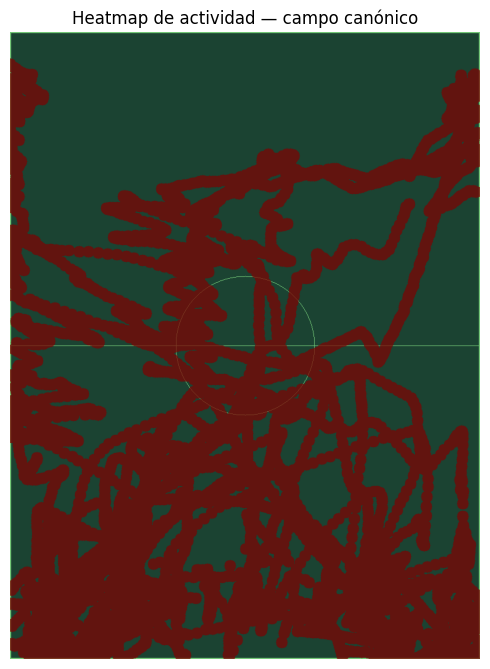

Heatmap guardado: assets/heatmap_final.png


In [117]:
# Normalizar y aplicar colormap al heatmap
heatmap_norm = cv2.normalize(heatmap_acc, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
heatmap_color = cv2.applyColorMap(heatmap_norm, cv2.COLORMAP_JET)

# Superponer sobre el fondo verde de la cancha
campo_fondo = np.zeros((CAMPO_H, CAMPO_W, 3), dtype=np.uint8)
campo_fondo[:] = (50, 67, 27)
cv2.rectangle(campo_fondo, (0, 0), (CAMPO_W-1, CAMPO_H-1), (120, 200, 116), 2)
cv2.line(campo_fondo, (0, CAMPO_H//2), (CAMPO_W, CAMPO_H//2), (120, 200, 116), 1)
cv2.circle(campo_fondo, (CAMPO_W//2, CAMPO_H//2), int(30*ESCALA_PX_CM), (120, 200, 116), 1)

mask_activa = heatmap_norm > 5
heatmap_final = campo_fondo.copy()
heatmap_final[mask_activa] = cv2.addWeighted(
    campo_fondo, 0.3, heatmap_color, 0.7, 0
)[mask_activa]

# Guardar y mostrar
cv2.imwrite(OUTPUT_HEATMAP, heatmap_final)

plt.figure(figsize=(5, 7))
plt.imshow(cv2.cvtColor(heatmap_final, cv2.COLOR_BGR2RGB))
plt.title("Heatmap de actividad — campo canónico")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_HEATMAP.replace(".png", "_plt.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Heatmap guardado: {OUTPUT_HEATMAP}")


## 8. Generar mapa de trayectorias (trails)

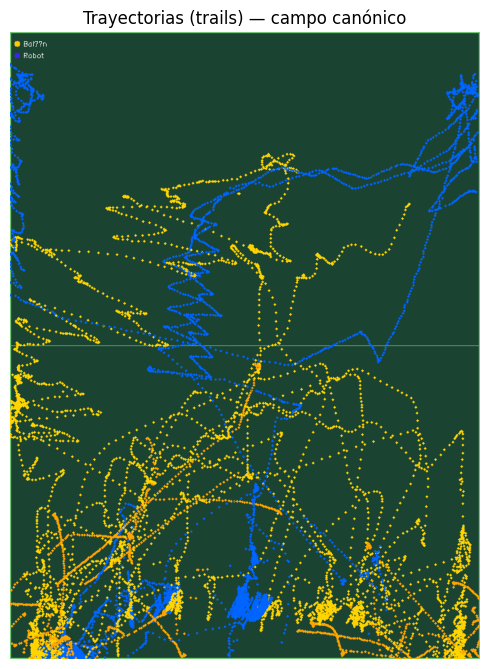

✓ Trails guardado: assets/trails_final.png


In [118]:
# Añadir leyenda al canvas de trails
leyenda_items = [
    ("Balón",  COLORS_BGR[0]),
    ("Robot",  COLORS_BGR[1]),
]
for i, (nombre, color) in enumerate(leyenda_items):
    y_pos = 20 + i * 20
    cv2.circle(trails_canvas, (12, y_pos), 5, color, -1)
    cv2.putText(trails_canvas, nombre, (22, y_pos+4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

cv2.imwrite(OUTPUT_TRAILS, trails_canvas)

plt.figure(figsize=(5, 7))
plt.imshow(cv2.cvtColor(trails_canvas, cv2.COLOR_BGR2RGB))
plt.title("Trayectorias (trails) — campo canónico")
plt.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_TRAILS.replace(".png", "_plt.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Trails guardado: {OUTPUT_TRAILS}")


## 9. Resumen de archivos generados

In [119]:
import os

archivos = [OUTPUT_PIPELINE, OUTPUT_HEATMAP, OUTPUT_TRAILS]
print("Archivos generados:")
for f in archivos:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / 1_000_000
        print(f"  ✓ {f} ({size_mb:.1f} MB)")
    else:
        print(f"  ✗ {f} — NO encontrado")

print("")
print("Próximos pasos:")
print("  1. Revisar pipeline_final.mp4 en VLC")
print("  2. Recortar los mejores 2 minutos para el video demo")
print("  3. Hacer el Reel de Instagram (≥30 segundos)")
print("  4. Agregar capturas al README.md")


Archivos generados:
  ✓ assets/pipeline_final.mp4 (123.0 MB)
  ✓ assets/heatmap_final.png (0.1 MB)
  ✓ assets/trails_final.png (0.1 MB)

Próximos pasos:
  1. Revisar pipeline_final.mp4 en VLC
  2. Recortar los mejores 2 minutos para el video demo
  3. Hacer el Reel de Instagram (≥30 segundos)
  4. Agregar capturas al README.md


## Diagnóstico

In [120]:
# Diagnóstico — corre esto una sola vez para ver dónde está la portería real
print(f"CAMPO_H total: {CAMPO_H}")
print(f"Zona de gol superior: y de 0 a {GROSOR_GOL_DETECTION_PX}")
print(f"Zona de gol inferior: y de {CAMPO_H - GROSOR_GOL_DETECTION_PX} a {CAMPO_H}")
print(f"Eso es el {GROSOR_GOL_DETECTION_PX/CAMPO_H*100:.1f}% del campo desde cada extremo")

CAMPO_H total: 1080
Zona de gol superior: y de 0 a 100
Zona de gol inferior: y de 980 a 1080
Eso es el 9.3% del campo desde cada extremo
